# Telco Customer Churn Analysis
**Business question:** Which customers are leaving, when, and how much revenue does it cost?
**Data:** 7,043 customers, 21 attributes (IBM sample dataset). **Tools:** Python, pandas, matplotlib.

In [1]:
import pandas as pd
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
print(df.shape)
df.info()

(7043, 21)
<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    


In [2]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
print(df["TotalCharges"].isna().sum())
df[df["TotalCharges"].isna()][["customerID", "tenure", "TotalCharges"]]

11


,customerID,tenure,TotalCharges
488,4472-LVYGI,0,NaN
753,3115-CZMZD,0,NaN
936,5709-LVOEQ,0,NaN
1082,4367-NUYAO,0,NaN
1340,1371-DWPAZ,0,NaN
3331,7644-OMVMY,0,NaN
3826,3213-VVOLG,0,NaN
4380,2520-SGTTA,0,NaN
5218,2923-ARZLG,0,NaN
6670,4075-WKNIU,0,NaN


In [3]:
df["TotalCharges"] = df["TotalCharges"].fillna(0)
df["ChurnFlag"] = (df["Churn"] == "Yes").astype(int)
print(df["ChurnFlag"].mean())

0.2653698707936959


Contract
Month-to-month    42.7
One year          11.3
Two year           2.8
Name: ChurnFlag, dtype: float64


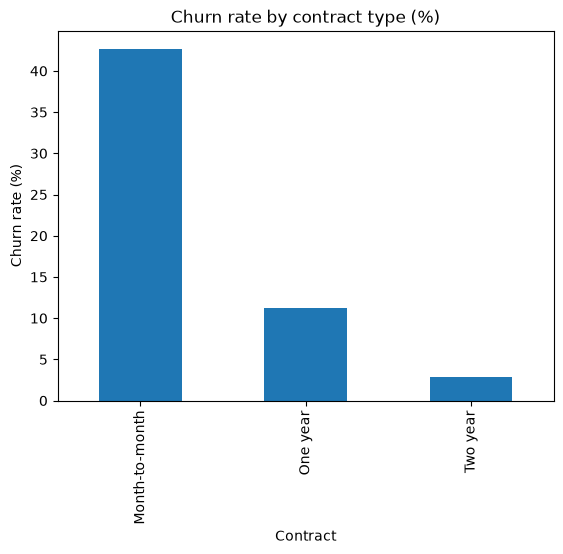

In [4]:
import matplotlib.pyplot as plt

rate = df.groupby("Contract")["ChurnFlag"].mean().sort_values(ascending=False) * 100
print(rate.round(1))

rate.plot(kind="bar", title="Churn rate by contract type (%)")
plt.ylabel("Churn rate (%)")
plt.show()

TenureGroup
0-12 mo     47.4
13-24 mo    28.7
25-48 mo    20.4
49-72 mo     9.5
Name: ChurnFlag, dtype: float64


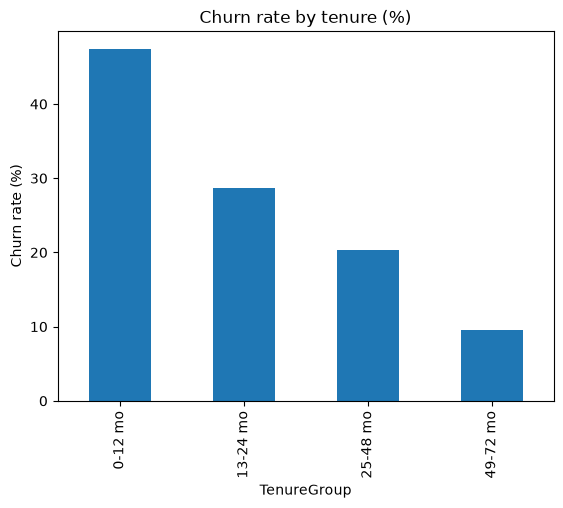

In [5]:
df["TenureGroup"] = pd.cut(df["tenure"], bins=[-1, 12, 24, 48, 72],
                           labels=["0-12 mo", "13-24 mo", "25-48 mo", "49-72 mo"])
rate = df.groupby("TenureGroup", observed=True)["ChurnFlag"].mean() * 100
print(rate.round(1))

rate.plot(kind="bar", title="Churn rate by tenure (%)")
plt.ylabel("Churn rate (%)")
plt.show()

InternetService
Fiber optic    41.9
DSL            19.0
No              7.4
Name: ChurnFlag, dtype: float64 

PaymentMethod
Electronic check             45.3
Mailed check                 19.1
Bank transfer (automatic)    16.7
Credit card (automatic)      15.2
Name: ChurnFlag, dtype: float64 



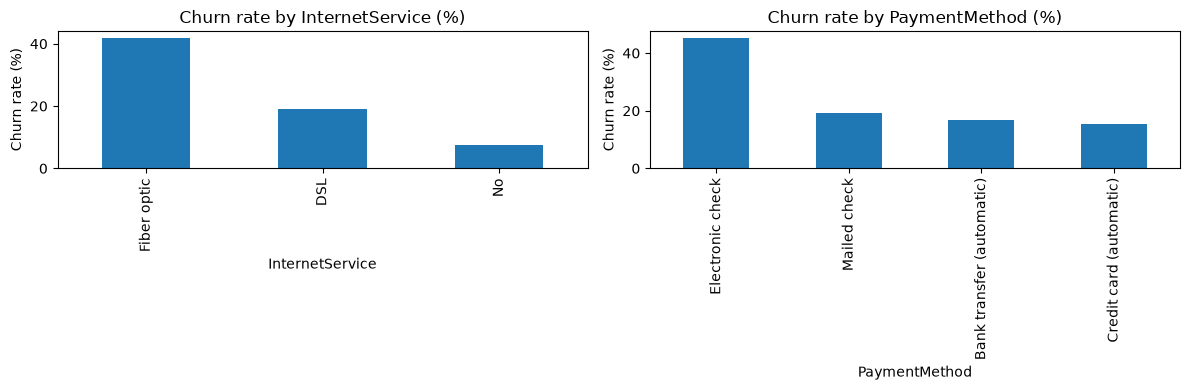

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, col in zip(axes, ["InternetService", "PaymentMethod"]):
    r = df.groupby(col)["ChurnFlag"].mean().sort_values(ascending=False) * 100
    print(r.round(1), "\n")
    r.plot(kind="bar", ax=ax, title=f"Churn rate by {col} (%)")
    ax.set_ylabel("Churn rate (%)")
plt.tight_layout()
plt.show()

In [7]:
lost = df.loc[df["ChurnFlag"] == 1, "MonthlyCharges"].sum()
total = df["MonthlyCharges"].sum()
print(f"Monthly revenue lost to churn: ${lost:,.0f} ({lost/total:.1%} of total)")

risk = df[(df["Contract"] == "Month-to-month")
          & (df["InternetService"] == "Fiber optic")
          & (df["PaymentMethod"] == "Electronic check")]
print(f"High-risk segment: {len(risk)} customers, churn rate {risk['ChurnFlag'].mean():.1%}")

Monthly revenue lost to churn: $139,131 (30.5% of total)
High-risk segment: 1307 customers, churn rate 60.4%


## Key findings
- **26.5%** of customers churned, taking **$139K/month (30.5% of revenue)** with them. Churners pay more than average, so the revenue loss is bigger than the customer loss.
- **Contract:** month-to-month churn is **42.7%** vs 2.8% on two-year contracts.
- **Timing:** **47.4%** of customers churn in year one, falling to 9.5% after four years.
- **Service and payment:** fiber optic (41.9%) and electronic check (45.3%) have the highest churn.
- **High-risk segment:** month-to-month + fiber + electronic check = 1,307 customers (19% of the base) churning at **60.4%**.

## Recommendations
1. Offer incentives to move month-to-month customers onto 1-2 year contracts.
2. Focus retention efforts on the first 12 months.
3. Encourage automatic payment, and test whether it lowers churn in the electronic-check group.
4. Investigate fiber optic pricing and service quality.

**Limitation:** this is a one-time snapshot, so it shows association, not cause.